# 1.Importing libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# 2.Load dataset & EDA

In [21]:
df = pd.read_csv("movie_recommendation_dataset.csv")
print("dataset Loaded successfully")

#EDA
df.head()
df.shape
df.info()
df.isnull().sum()

#Most Common Genres
df['genres'].str.split('|').explode().value_counts().head(5)

#Unique Movies & Users
print("Unique Movies:", df['movieId'].nunique())
print("Unique Users:", df['userId'].nunique())



dataset Loaded successfully
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   movieId   600 non-null    int64  
 1   title     600 non-null    object 
 2   genres    600 non-null    object 
 3   overview  600 non-null    object 
 4   userId    600 non-null    int64  
 5   rating    600 non-null    float64
dtypes: float64(1), int64(2), object(3)
memory usage: 28.3+ KB
Unique Movies: 119
Unique Users: 80


# 3.Metadata Cleaning

In [22]:
df.drop_duplicates(inplace=True)
df['overview'] = df['overview'].fillna('')
df['genres'] = df['genres'].fillna('')
df['overview'] = df['overview'].str.lower()
df['genres'] = df['genres'].str.lower()
df['combined_features'] = df['genres'] + " " + df['overview']
print("metadata cleaning is successfully completed.!")

metadata cleaning is successfully completed.!


# 4.Content Based recommender

In [23]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_features'])
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
def recommend_movies(movie_title, cosine_sim=cosine_sim):
    if movie_title not in df['title'].values:
        return "Movie not found in dataset"
    
    idx = df[df['title'] == movie_title].index[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    
    movie_indices = [i[0] for i in sim_scores]
    
    return df[['title', 'genres']].iloc[movie_indices]


TF-IDF Matrix Shape: (600, 31)


# 5.Visualizations

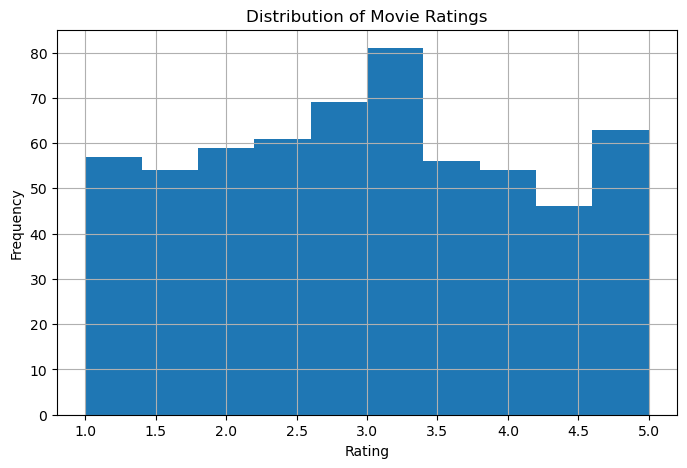

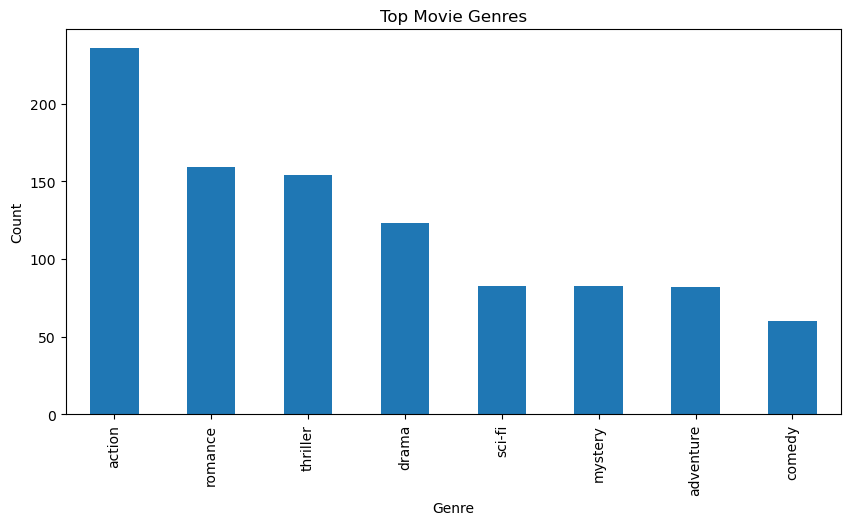

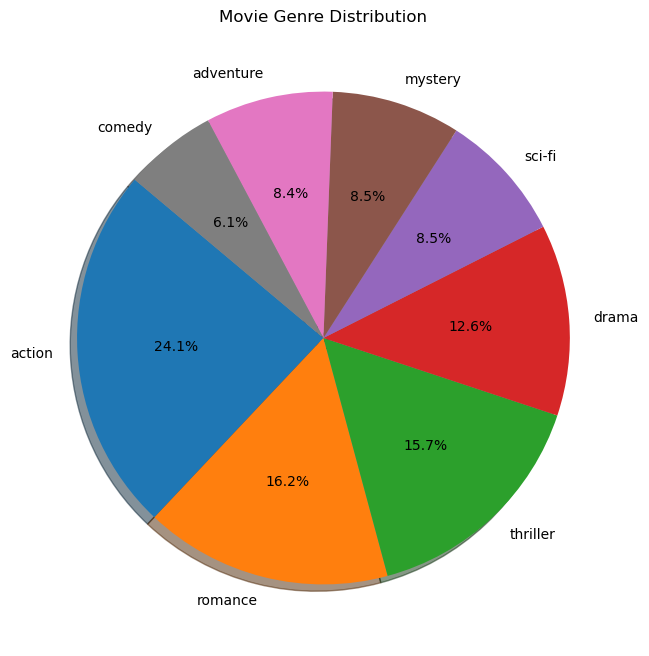

In [24]:
#Graph 1: Rating Distribution

plt.figure(figsize=(8,5))
df['rating'].hist(bins=10)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Movie Ratings")
plt.show()

#Graph 2: Genre Popularity

genre_count = df['genres'].str.split('|').explode().value_counts()
plt.figure(figsize=(10,5))
genre_count.head(10).plot(kind='bar')
plt.xlabel("Genre")
plt.ylabel("Count")
plt.title("Top Movie Genres")
plt.show()

# Graph 3: Plot pie chart

plt.figure(figsize=(8,8))
genre_count.plot(kind='pie', autopct='%1.1f%%', startangle=140, shadow=True)
plt.title("Movie Genre Distribution")
plt.ylabel("")  # Remove default ylabel
plt.show()


# 6.Sample of Qualitative Evaluation 

In [25]:
print("\nRecommendations for 'Final Algorithm':")
print(recommend_movies("Final Algorithm"))

print("\nRecommendations for 'Echoes of Love':")
print(recommend_movies("Echoes of Love"))



Recommendations for 'Final Algorithm':
                  title   genres
8    Beyond the Horizon  romance
68        Shadow Hunter  romance
112  Beyond the Horizon  romance
157      Broken Destiny  romance
188        Lost in Time  romance

Recommendations for 'Echoes of Love':
                  title  genres
9        Broken Destiny  comedy
23   Dream Beyond Stars  comedy
63         Lost in Time  comedy
120        Quantum Love  comedy
174       Shadow Hunter  comedy
